In [1]:
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from pathlib import Path
import sys
# --------------- Set up project root path  --------------- #
project_folder_name = "MFC2024" # Set this to the name of your project root folderS
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if p.name == project_folder_name), None)
if project_root is None:
    raise FileNotFoundError(f"Could not locate project root folder named '{project_folder_name}'.")
print("Project root path:", project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from configuration.settings import *
from model.fuelcell import PEMFC_1D
from model.coefficients import *
from configuration.initialize import *


Project root path: d:\PEMFC\MFC2024


In [2]:
Hcl, Hgdl, Hmem = parameters['Hcl'], parameters['Hgdl'], parameters['Hmem']
Lgc, Wgc, Hgc = parameters['Lgc'], parameters['Wgc'], parameters['Hgc']
mu_l = 3.56e-4 # Pa.s, viscosity of liquid water at 80C
mu_g = 1.881e-5 # Pa.s, viscosity of water vapor at cathode

In [3]:
Phi_a_des, Phi_c_des, Tfc = operating_inputs['Phi_a_des'], operating_inputs['Phi_c_des'], operating_inputs['Tfc']
Pa_des, Pc_des = operating_inputs['Pa_des'], operating_inputs['Pc_des']
Win_c, Wout_c = operating_inputs['Win_c'], operating_inputs['Wout_c']
Win_a, Wout_a = operating_inputs['Win_a'], operating_inputs['Wout_a']

i = 1.2e4 # current density (A/m^2)

In [4]:
### Define the water flow at CCL
Srxn = i / (2 * F) # mol/s/m^2
### Water inlet
Cv_in_a = Phi_a_des * Csat(Tfc)
Cv_in_c = Phi_c_des * Csat(Tfc)

In [5]:
def gdl_profile(Jw, Vgin_ca, Vgout_ca):

    s = np.zeros(10)
    C_v_gdl = np.zeros(10)
    C_v_gc = (Jw * parameters["Lgc"] / parameters["Hgc"] + Cv_in_c * Win_c)/Wout_c

    # ------------------- Case 1: CL -> GC ------------------- #
    if Jw > 0:
        # -------- Boundary conditions -------- #
        C_v_inter = C_v_gc + Jw/h_conv(Pc_des, Tfc, parameters["Wgc"], parameters["Hgc"])
        C_v_cl = C_v_inter + Hgdl/Dc(Pc_des, Tfc) * Jw
        # ------------------- Regime M ------------------- #
        if C_v_cl > Csat(Tfc) and C_v_gc < Csat(Tfc):
            x_front = (Csat(Tfc) - C_v_inter) * (Dc(Pa_des, Tfc) / Jw)
            i_node = 0
            for x in np.linspace(0, Hgdl, 10):
                C_v_gdl[i_node] = np.min([C_v_inter + (x)/Dc(Pc_des, Tfc) * Jw, Csat(Tfc)])
                def s_gdl_func(n):
                    rhs = (M_H2O * Jw * (x - x_front)) / (-sigma(Tfc) * K0(epsilon_gdl, epsilon_c)/nu_l(Tfc)* np.cos(theta_c)*(epsilon_gdl/K0(epsilon_gdl,epsilon_c))**0.5)
                    return 0.35425 * n ** 4 - 0.848 * n **5 + 0.6315 * n ** 6 - rhs
                s[i_node] = np.max([fsolve(s_gdl_func, x0=0.05)[0], 0])
                i_node += 1
        # ------------------- Regime L ------------------- #
        elif C_v_gc > Csat(Tfc) and C_v_cl > Csat(Tfc):
            mliquid = M_H2O * (Jw + (Vgin_ca - Vgout_ca) * parameters["Hgc"]/parameters["Lgc"])
            ans1 = (mliquid * parameters["Lgc"] * mu_l/ (parameters["Hgc"] * rho_H2O(Tfc) * mu_g)) ** (1/3)
            s_gdl_inter = ans1 / (ans1 + 1)
            x_front = Hgdl
            i_node = 0
            for x in np.linspace(0, Hgdl, 10):
                C_v_gdl[i_node] = Csat(Tfc)
                def s_gdl_func(n):
                    rhs = (M_H2O * Jw * (x)) /(-sigma(Tfc) * K0(epsilon_gdl, epsilon_c)/nu_l(Tfc)* np.cos(theta_c)*(epsilon_gdl/K0(epsilon_gdl,epsilon_c))**0.5) + \
                             0.35425 * s_gdl_inter ** 4 - 0.848 * s_gdl_inter **5 + 0.6315 * s_gdl_inter ** 6 
                    return 0.35425 * n ** 4 - 0.848 * n **5 + 0.6315 * n ** 6 - rhs
                s[i_node] = np.max([fsolve(s_gdl_func, x0=0.05)[0], 0])
                i_node += 1
        # ------------------- Regime V ------------------- #
        else: 
            x_front = 0
            i_node = 0
            for x in np.linspace(0, Hgdl, 10):
                C_v_gdl[i_node] = C_v_inter + (x)/Dc(Pc_des, Tfc) * Jw
                i_node += 1
    # ------------------- Case 2: GC -> CL ------------------- #
    elif Jw < 0: 
        # -------- Boundary conditions -------- #
        C_v_inter = C_v_gc + Jw/h_conv(Pc_des, Tfc, parameters["Wgc"], parameters["Hgc"])
        C_v_cl = C_v_inter + Hgdl/Dc(Pc_des, Tfc) * Jw
        mliquid = M_H2O * (Jw + (Vgin_ca - Vgout_ca) * parameters["Hgc"]/parameters["Lgc"])
        ans1 = (mliquid * parameters["Lgc"] * mu_l/ (parameters["Hgc"] * rho_H2O(Tfc) * mu_g)) ** (1/3)
        s_gdl_inter = ans1 / (ans1 + 1)
        rhs = (-sigma(Tfc) * K0(epsilon_gdl, epsilon_c)/nu_l(Tfc)* np.cos(theta_c)*(epsilon_gdl/K0(epsilon_gdl,epsilon_c))**0.5)
        x_front = (0.35425 *s_gdl_inter ** 4 - 0.848 *  s_gdl_inter**5 + 0.6315 *  s_gdl_inter ** 6 * rhs / (M_H2O * Jw))
        # ------------------- Regime V ------------------- #
        if  C_v_gc <= Csat(Tfc):
            x_front = 0
            i_node = 0
            for x in np.linspace(0, Hgdl, 10):
                C_v_gdl[i_node] = C_v_inter + (x)/Dc(Pc_des, Tfc) * Jw
                i_node += 1
        else:
            mliquid = M_H2O * (Jw + (Vgin_ca - Vgout_ca) * parameters["Hgc"]/parameters["Lgc"])
            ans1 = (mliquid * parameters["Lgc"] * mu_l/ (parameters["Hgc"] * rho_H2O(Tfc) * mu_g)) ** (1/3)
            s_gdl_inter = ans1 / (ans1 + 1)
            rhs = (-sigma(Tfc) * K0(epsilon_gdl, epsilon_c)/nu_l(Tfc)* np.cos(theta_c)*(epsilon_gdl/K0(epsilon_gdl,epsilon_c))**0.5)
            xliquid =  (0.35425 *s_gdl_inter ** 4 - 0.848 *  s_gdl_inter**5 + 0.6315 *  s_gdl_inter ** 6 * rhs / (M_H2O * Jw))
        # ------------------- Regime M ------------------- #
            if xliquid < parameters["Hgdl"]: # Regime M
                i_node = 0
                for x in np.linspace(0, Hgdl, 10):
                    C_v_gdl[i_node] = np.min([Csat(Tfc) + (x - x_front)/Dc(Pc_des, Tfc) * Jw, Csat(Tfc)])
                    def s_gdl_func(n):
                        rhs = (M_H2O * Jw * (x)) / (-sigma(Tfc) * K0(epsilon_gdl, epsilon_c)/nu_l(Tfc)* np.cos(theta_c)*(epsilon_gdl/K0(epsilon_gdl,epsilon_c))**0.5) + \
                                 0.35425 * s_gdl_inter ** 4 - 0.848 * s_gdl_inter **5 + 0.6315 * s_gdl_inter ** 6 
                        return 0.35425 * n ** 4 - 0.848 * n **5 + 0.6315 * n ** 6 - rhs
                    s[i_node] = np.max([fsolve(s_gdl_func, x0=0.05)[0], 0])
                    i_node += 1
        # ------------------- Regime L ------------------- #
            else: 
                x_front = Hgdl
                i_node = 0
                for x in np.linspace(0, Hgdl, 10):
                    C_v_gdl[i_node] = Csat(Tfc)
                    def s_gdl_func(n):
                        rhs = (M_H2O * Jw * (x)) / (-sigma(Tfc) * K0(epsilon_gdl, epsilon_c)/nu_l(Tfc)* np.cos(theta_c)*(epsilon_gdl/K0(epsilon_gdl,epsilon_c))**0.5) + \
                                 0.35425 * s_gdl_inter ** 4 - 0.848 * s_gdl_inter **5 + 0.6315 * s_gdl_inter ** 6 
                        return 0.35425 * n ** 4 - 0.848 * n **5 + 0.6315 * n ** 6 - rhs
                    s[i_node] = fsolve(s_gdl_func, x0=0.05)[0]
                    i_node += 1
    # ------------------- Case 3: No water flow ------------------- #
    else: 
        # -------- Boundary conditions -------- #
        C_v_inter = C_v_gc
        C_v_cl = C_v_inter 
        xliquid = 0
        # ------------------- Determine the regime in GDL ------------------- #
        if C_v_gc > Csat(Tfc): # Regime L
            x_front = Hgdl
            i_node = 0
            for x in np.linspace(0, Hgdl, 10):
                C_v_gdl[i_node] = Csat(Tfc)
                def s_gdl_func(n):
                    rhs = 0
                    return 0.35425 * n ** 4 - 0.848 * n **5 + 0.6315 * n ** 6 - rhs
                s[i_node] = np.max([fsolve(s_gdl_func, x0=0.05)[0], 0])
                i_node += 1
        else: # Regime V
            x_front = 0
            i_node = 0
            for x in np.linspace(0, Hgdl, 10):
                C_v_gdl[i_node] = C_v_inter
                i_node += 1
    return C_v_gdl, C_v_cl, C_v_inter, s, x_front

In [6]:
Jnet = 0 # net water flux (positive if water flows from CL to GC)
Jw_ca = i / (2 * F) 
Jw_an = 0
C_v_cgdl, C_v_ccl, C_v_cinter, s_cgdl, x_front_c = gdl_profile(Jw_ca, Win_c, Wout_c)
C_v_agdl, C_v_acl, C_v_ainter, s_agdl, x_front_a = gdl_profile(Jw_an, Win_a, Wout_a)
# Water content
if Jw_ca > 0:
    if C_v_ccl > Csat(Tfc):
        lambda_ccl = np.min([14 + 8*s_cgdl[0], 22])
    else:
        lambda_ccl = np.min([lambda_eq(C_v_ccl, 0, Tfc, 20) + Jw_ca * M_eq / (epsilon_cl * Hcl * 1.3 *rho_mem) , 14])
else:
    lambda_ccl = lambda_eq(C_v_ccl, 0, Tfc, 20) + Jw_ca * M_eq / (epsilon_cl * Hcl * 1.3 *rho_mem) 

Klambda = rho_mem/M_eq * Dw(lambda_ccl, Tfc) / (2.5/22 * i / F)
lambda_acl = lambda_ccl * np.exp(-parameters["Hmem"]/Klambda)
lambda_mem = [lambda_ccl * np.exp(-x/Klambda) for x in np.linspace(0, 2e-5, 10)]

C:\Users\yukwa\AppData\Local\Temp\ipykernel_27064\3601507423.py:36: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  s[i_node] = np.max([fsolve(s_gdl_func, x0=0.05)[0], 0])


In [7]:
success = False

while success == False:

    Jw_ca = i / (2 * F) - Jnet
    Jw_an = Jnet
    C_v_cgdl, C_v_ccl, C_v_cinter, s_cgdl, x_front_c = gdl_profile(Jw_ca, Win_c, Wout_c)
    C_v_agdl, C_v_acl, C_v_ainter, s_agdl, x_front_a = gdl_profile(Jw_an, Win_a, Wout_a)

    # Water content
    if C_v_ccl > Csat(Tfc):
        lambda_ccl = np.min([14 + 8*s_cgdl[0], 22])
    else:
        lambda_ccl = np.min([lambda_eq(C_v_ccl, 0, Tfc, 20) + Jw_ca * M_eq / (epsilon_cl * Hcl * 1.3 *rho_mem) , 14])
    if C_v_acl > Csat(Tfc):
        lambda_acl = np.min([14 + 8*s_agdl[0], 22])
    else:
        lambda_acl = np.min([lambda_eq(C_v_acl, 0, Tfc, 20) + Jw_an * M_eq / (epsilon_cl * Hcl * 1.3 *rho_mem) , 14])

    Klambda = rho_mem/M_eq * Dw(lambda_ccl, 333.15) / (2.5/22 * i / F)
    lambda_mem = [(1-np.exp(-x/Klambda))/(1-np.exp(parameters["Hmem"]/Klambda)) *
                                (lambda_acl - lambda_ccl) * np.exp(-parameters["Hmem"]/Klambda) +
                                 lambda_ccl * np.exp(-x/Klambda) for x in np.linspace(0, parameters["Hmem"], 10)]

    Jmem = -2.5/22 * i / F * (lambda_ccl* np.exp(-parameters["Hmem"]/Klambda) - lambda_acl) / (np.exp(-parameters["Hmem"]/Klambda) - 1)

    if abs(Jnet - Jmem) <= 1e-4:
        success = True
    else:
        Jnet += 0.1 * (Jmem - Jnet)
        print(f"Current guess for Jnet: {Jnet:.6f}, Jmem: {Jmem:.6f}, Difference: {abs(Jnet - Jmem):.6f}")

Current guess for Jnet: 0.010179, Jmem: 0.101792, Difference: 0.091613
Current guess for Jnet: 0.008291, Jmem: -0.008703, Difference: 0.016994
Current guess for Jnet: 0.008715, Jmem: 0.012532, Difference: 0.003817
Current guess for Jnet: 0.008627, Jmem: 0.007839, Difference: 0.000788
Current guess for Jnet: 0.008646, Jmem: 0.008811, Difference: 0.000165


C:\Users\yukwa\AppData\Local\Temp\ipykernel_27064\3601507423.py:36: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  s[i_node] = np.max([fsolve(s_gdl_func, x0=0.05)[0], 0])


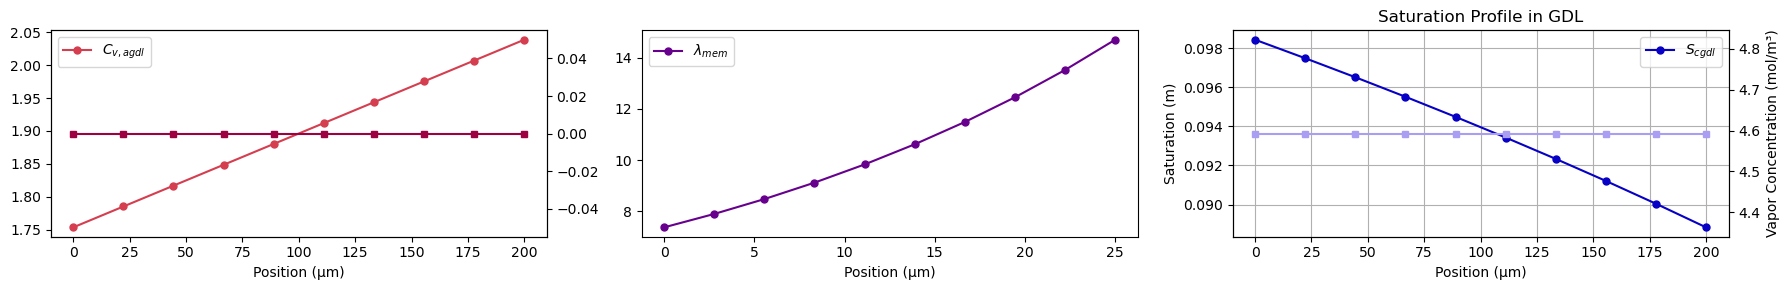

In [8]:
fig, axes = plt.subplots(nrows=1, ncols= 3, figsize=(18, 3))
axes[0].plot(np.linspace(0, Hgdl*1e6, 10), C_v_agdl, marker='o', markersize=5, color = "#d53e4f", label = "$C_{v, agdl}$")
ax2 = axes[0].twinx()
ax2.plot(np.linspace(0, Hgdl*1e6, 10), s_agdl, marker='s', markersize=5, color = "#9e0142", label = "$S_{agdl}$")
axes[0].set_xlabel('Position (µm)')
axes[1].plot(np.linspace(0, parameters["Hmem"]*1e6, 10), lambda_mem[::-1], marker='o', markersize=5, color = "#67008d", label = r"$\lambda_{mem}$")
axes[1].set_xlabel('Position (µm)')
axes[2].plot(np.linspace(0, Hgdl*1e6, 10), s_cgdl[::-1], marker='o', markersize=5, color = "#0700c5", label = "$S_{cgdl}$")
ax2 = axes[2].twinx()
ax2.plot(np.linspace(0, Hgdl*1e6, 10), C_v_cgdl[::-1], marker='s', markersize=5, color = "#aa9ef2", label = "$C_{v, cgdl}$")
axes[2].set_xlabel('Position (µm)')
axes[2].set_ylabel('Saturation (m)')
axes[2].set_title('Saturation Profile in GDL')
axes[2].grid(True)
ax2.set_ylabel('Vapor Concentration (mol/m³)')
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()